# Spoken English Grammar Scoring Engine

## Project objective

The objective is to predict a **0–5 grammar score from spoken-English audio**.  
The training set contains labelled recordings, while the test set contains recordings for which the score must be predicted.

The modelling strategy treats grammar scoring as a **multimodal regression problem**:

**Audio → speech recognition → linguistic features + acoustic/prosodic features + pretrained speech/text representations → leakage-safe cross-validation → ensemble selection → final test prediction**

### Methodology

1. **Dataset discovery and integrity checks**
   - Locate the competition CSV files and WAV recordings already available in the Colab runtime.
   - Resolve audio paths robustly even when the ZIP contains nested train/test folders.
   - Verify that training labels are numeric and lie in the expected 0–5 range.
   - Keep test labels completely isolated from the modelling pipeline.

2. **Audio quality and preprocessing**
   - Validate that every required WAV can be decoded.
   - Convert audio to mono 16 kHz for consistent downstream processing.
   - Preserve pauses and hesitations because they can contain useful information about spoken fluency.

3. **Acoustic and prosodic modelling**
   - Extract energy, spectral, MFCC, pitch and timing statistics.
   - Capture speech-rate and pause-related characteristics that are not recoverable from a transcript alone.

4. **Automatic speech recognition**
   - Generate English transcripts with word-level timing and confidence information.
   - Cache transcripts so repeated notebook runs do not repeat completed inference.

5. **Linguistic and grammar features**
   - Build lexical, repetition, filler and timing features from the transcript.
   - Add pretrained grammatical acceptability, language-model fluency and rule-based grammar signals when the corresponding libraries/models are available.

6. **Pretrained representations**
   - Extract self-supervised speech representations from pretrained audio encoders.
   - Extract sentence-level transcript embeddings.
   - Probe representation layers using training-only cross-validation rather than using test labels.

7. **Leakage-safe model selection**
   - Use stratified/grouped repeated cross-validation.
   - Compare complementary regressors instead of assuming one model family is optimal.
   - Build the final blend from out-of-fold predictions.

8. **Final prediction and submission**
   - Retrain the selected components using all labelled training examples.
   - Predict the exact rows in `test.csv`.
   - Clip predictions to the valid 0–5 range.
   - Validate the final CSV before saving it as `submission.csv`

In [ ]:
# ============================================================
# 1. CONFIG + IMPORTS
# ============================================================
import os, re, json, math, random, warnings, zipfile, hashlib, time, sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from IPython.display import display
from scipy.stats import pearsonr

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules

ZIP_PATH       = Path("/content/shl-hiring-assessment-2026.zip")
EXTRACT_PATH   = Path("/content/shl_data")
OUTPUT_DIR     = Path("/content/grammar_scoring_outputs")
CACHE_ON_DRIVE = False

USE_ASR          = True
ASR_MODEL_SIZE   = "small.en"
ASR_KEEP_FILLERS = True
USE_COLA         = True
USE_GPT2_LM      = True
USE_LANGUAGETOOL = True
USE_SSL          = True
SSL_MODELS       = ["microsoft/wavlm-base-plus", "facebook/wav2vec2-base-960h"]
USE_TEXT_EMB     = True


SEED      = 42
N_FOLDS   = 5
N_REPEATS = 2
TARGET_SR = 16000

random.seed(SEED); np.random.seed(SEED)

if CACHE_ON_DRIVE and "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_DIR = Path("/content/drive/MyDrive/grammar_scoring_outputs")

CACHE_DIR = OUTPUT_DIR / "cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    torch, DEVICE = None, "cpu"

print("Device:", DEVICE, "| LightGBM:", HAS_LGBM)
if DEVICE == "cpu" and (USE_ASR or USE_SSL):
    print("WARNING: no GPU detected. ASR/SSL will be very slow - switch the Colab runtime to GPU.")


# ------------------------- cache helpers -----------------
def cached_table(cache_name, keys, compute_fn):
    """Per-file feature table cached as parquet. Only missing keys are computed."""
    path = CACHE_DIR / cache_name
    old = pd.read_parquet(path) if path.exists() else pd.DataFrame()
    have = set(old.index)
    todo = [k for k in keys if k not in have]
    if todo:
        print(f"[{cache_name}] computing {len(todo)}/{len(keys)} files")
        rows = compute_fn(todo)
        new = pd.DataFrame(rows, index=todo)
        tbl = pd.concat([old, new]) if len(old) else new
        if tbl.shape[1] > 0:
            tbl.to_parquet(path)
    else:
        tbl = old
        print(f"[{cache_name}] loaded from cache ({len(keys)} files)")
    return tbl.reindex(keys)


def cached_array(cache_name, keys, compute_fn):
    """Per-file ndarray cache (first axis = file). Only missing keys are computed."""
    path = CACHE_DIR / cache_name
    store = {}
    if path.exists():
        z = np.load(path, allow_pickle=False)
        store = {k: a for k, a in zip(z["keys"].tolist(), z["arr"])}
    todo = [k for k in keys if k not in store]
    if todo:
        print(f"[{cache_name}] computing {len(todo)}/{len(keys)} files")
        arr = compute_fn(todo)
        store.update({k: a for k, a in zip(todo, arr)})
        ks = list(store.keys())
        np.savez(path, keys=np.array(ks), arr=np.stack([store[k] for k in ks]))
    else:
        print(f"[{cache_name}] loaded from cache ({len(keys)} files)")
    return np.stack([store[k] for k in keys])


def parallel_rows(fn, paths, desc):
    return Parallel(n_jobs=-1)(delayed(fn)(p) for p in tqdm(paths, desc=desc))

Device: cuda | LightGBM: True


In [ ]:
# ============================================================
# 2. DATA DISCOVERY - folder-aware audio resolution
# ============================================================
EXTRACT_PATH.mkdir(parents=True, exist_ok=True)
if not any(EXTRACT_PATH.iterdir()):
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"Upload the competition ZIP to {ZIP_PATH} and rerun.")
    print("Extracting ZIP ...")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(EXTRACT_PATH)

WAVS = sorted(p for p in EXTRACT_PATH.rglob("*")
              if p.is_file() and p.suffix.lower() in {".wav", ".wave"})
BY_NAME = {}
for p in WAVS:
    BY_NAME.setdefault(p.name.lower(), []).append(p)

print(f"WAV files: {len(WAVS)}")
print("\nWAV files per folder:")
print(pd.Series([str(p.parent.relative_to(EXTRACT_PATH)) for p in WAVS]).value_counts().to_string())
n_collide = sum(len(v) > 1 for v in BY_NAME.values())
print(f"\nBasenames that exist in more than one folder: {n_collide}")


def find_csv(name):
    m = sorted(EXTRACT_PATH.rglob(name))
    if not m:
        raise FileNotFoundError(f"{name} not found under {EXTRACT_PATH}")
    return m[0]

TRAIN_CSV, TEST_CSV, SAMPLE_CSV = (find_csv(n) for n in ["train.csv", "test.csv", "sample_submission.csv"])


def rel_key(p):
    return str(Path(p).relative_to(EXTRACT_PATH)).replace("\\", "/")


def _in_split(p, split):
    parts = [x.lower() for x in Path(p).relative_to(EXTRACT_PATH).parts[:-1]]
    return any(split in x for x in parts)


def resolve_audio(name, split):
    """Resolve a CSV filename to a WAV. split in {'train','test'} selects the right folder
    when the same basename exists in several folders (the bug in the previous notebook)."""
    if pd.isna(name):
        return None
    norm = str(name).strip().replace("\\", "/")
    direct = EXTRACT_PATH / norm
    if direct.is_file():
        return direct
    cands = BY_NAME.get(Path(norm).name.lower(), [])
    if not cands:
        return None
    hinted = [p for p in cands if _in_split(p, split)]
    if hinted:
        return hinted[0]
    opposite = "train" if split == "test" else "test"
    other = [p for p in cands if not _in_split(p, opposite)]
    return (other or cands)[0]

WAV files: 985

WAV files per folder:
Dataset_Final/train    769
Dataset_Final/test     216

Basenames that exist in more than one folder: 212


In [ ]:
# ============================================================
# 3. LOAD CSVs + TEST-LABEL FIREWALL + SUBMISSION TARGET
# ============================================================
train_df    = pd.read_csv(TRAIN_CSV)
test_raw_df = pd.read_csv(TEST_CSV)
sample_df   = pd.read_csv(SAMPLE_CSV)

print("train :", train_df.shape, train_df.columns.tolist())
print("test  :", test_raw_df.shape, test_raw_df.columns.tolist())
print("sample:", sample_df.shape, sample_df.columns.tolist())

FILE_COL  = "filename" if "filename" in train_df.columns else train_df.select_dtypes("object").columns[0]
LABEL_COL = "label" if "label" in train_df.columns else [c for c in train_df.columns if c != FILE_COL][0]
SAMPLE_FILE_COL = "filename" if "filename" in sample_df.columns else sample_df.columns[0]
SAMPLE_LABEL_COL = [c for c in sample_df.columns if c != SAMPLE_FILE_COL][0]
TEST_FILE_COL = "filename" if "filename" in test_raw_df.columns else test_raw_df.columns[0]

train_df[LABEL_COL] = pd.to_numeric(train_df[LABEL_COL], errors="raise")
assert train_df[LABEL_COL].between(0, 5).all(), "training labels outside [0, 5]"

test_csv_df = test_raw_df[[TEST_FILE_COL]].rename(columns={TEST_FILE_COL: "filename"}).copy()
sample_df = sample_df.rename(columns={SAMPLE_FILE_COL: "filename"})

train_df["path"]    = train_df[FILE_COL].map(lambda n: resolve_audio(n, "train"))
test_csv_df["path"] = test_csv_df["filename"].map(lambda n: resolve_audio(n, "test"))
sample_df["path"]   = sample_df["filename"].map(lambda n: resolve_audio(n, "test"))

for d in (train_df, test_csv_df, sample_df):
    d["key"] = d["path"].map(lambda p: rel_key(p) if p is not None and not pd.isna(p) else None)

print("\nUnresolved  train:", train_df["key"].isna().sum(),
      "| test.csv:", test_csv_df["key"].isna().sum(),
      "| sample:", sample_df["key"].isna().sum())
if train_df["key"].isna().any():
    raise ValueError("Some training WAVs could not be resolved.")

train_names  = set(train_df[FILE_COL].str.lower())
test_names   = set(test_csv_df["filename"].str.lower())
sample_names = set(sample_df["filename"].str.lower())
print("\nFilename overlap  test.csv & train.csv :", len(test_names & train_names))
print("Filename overlap  sample   & train.csv :", len(sample_names & train_names))
print("Filename overlap  sample   & test.csv  :", len(sample_names & test_names))

in_train_folder = test_csv_df["path"].map(lambda p: bool(pd.notna(p)) and _in_split(p, "train")).sum()
print(f"test.csv rows resolved to a file inside a 'train' folder: {in_train_folder}")
shared_paths = set(test_csv_df["key"].dropna()) & set(train_df["key"])
print(f"test.csv rows resolving to the SAME file as a labelled train row: {len(shared_paths)}")
if shared_paths:
    print("  -> WARNING: predictions for these rows would be made on training audio. "
          "Check the ZIP layout (is there a separate test folder?).")

sample_ok = sample_df["key"].notna().mean()
PRIMARY = "sample" if sample_ok >= 0.95 else "test"
print(f"\nsample_submission rows resolvable to audio: {sample_ok:.1%}")
print(f"Primary submission template: {'sample_submission.csv' if PRIMARY=='sample' else 'test.csv'}")
print("(an alternate submission for the other file is also written at the end)")

pred_keys = list(dict.fromkeys(
    list(test_csv_df["key"].dropna()) + list(sample_df["key"].dropna())))
train_keys = train_df["key"].tolist()
AUDIO_KEYS = list(dict.fromkeys(train_keys + pred_keys))
KEY2PATH = {}
for d in (train_df, test_csv_df, sample_df):
    for k, p in zip(d["key"], d["path"]):
        if k is not None and not pd.isna(k):
            KEY2PATH[k] = str(p)
KEY_IDX = {k: i for i, k in enumerate(AUDIO_KEYS)}
y = train_df[LABEL_COL].astype(float).values

print(f"\nTrain files: {len(train_keys)} | files to predict: {len(pred_keys)} | unique audio files: {len(AUDIO_KEYS)}")
display(train_df[[FILE_COL, LABEL_COL, "key"]].head())

train : (769, 2) ['filename', 'label']
test  : (216, 2) ['filename', 'label']
sample: (204, 2) ['filename', 'label']

Unresolved  train: 0 | test.csv: 0 | sample: 99

Filename overlap  test.csv & train.csv : 212
Filename overlap  sample   & train.csv : 105
Filename overlap  sample   & test.csv  : 25
test.csv rows resolved to a file inside a 'train' folder: 0
test.csv rows resolving to the SAME file as a labelled train row: 0

sample_submission rows resolvable to audio: 51.5%
Primary submission template: test.csv
(an alternate submission for the other file is also written at the end)

Train files: 769 | files to predict: 296 | unique audio files: 985


,filename,label,key
0,audio_192.wav,3.0,Dataset_Final/train/audio_192.wav
1,audio_436.wav,3.0,Dataset_Final/train/audio_436.wav
2,audio_447.wav,3.5,Dataset_Final/train/audio_447.wav
3,audio_126.wav,2.0,Dataset_Final/train/audio_126.wav
4,audio_61.wav,2.0,Dataset_Final/train/audio_61.wav


Label summary:
count    769.000
mean       3.313
std        1.239
min        0.000
25%        2.500
50%        3.000
75%        4.000
max        5.000

Distinct label values: [np.float64(0.0), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]

Predict-the-mean baseline RMSE: 1.2382   (anything above this is worthless)


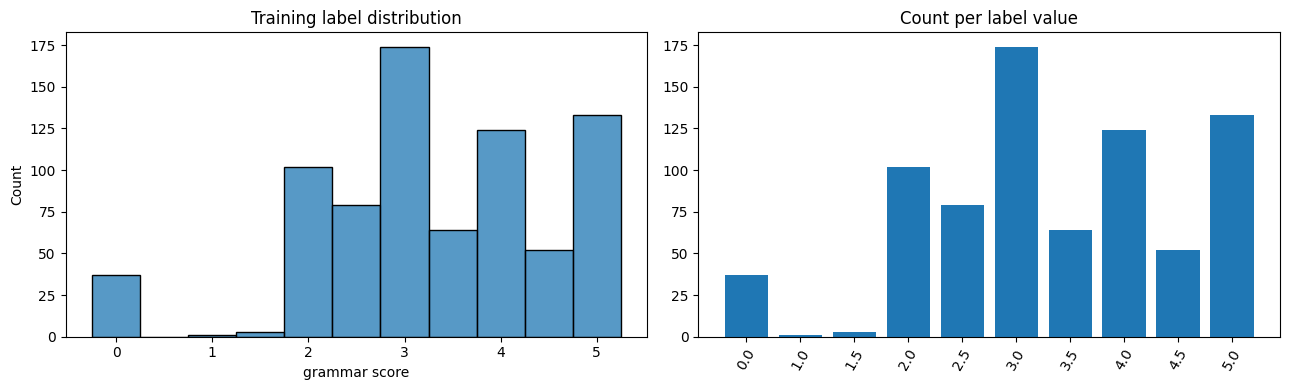

In [ ]:
# ============================================================
# 4. EDA - labels
# ============================================================
print("Label summary:")
print(train_df[LABEL_COL].describe().round(3).to_string())
print("\nDistinct label values:", sorted(train_df[LABEL_COL].unique()))
print(f"\nPredict-the-mean baseline RMSE: {y.std():.4f}   (anything above this is worthless)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(y, bins=np.arange(-0.25, 5.26, 0.5), ax=axes[0])
axes[0].set_title("Training label distribution"); axes[0].set_xlabel("grammar score")
vc = pd.Series(y).value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values)
axes[1].set_title("Count per label value"); axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

[audio_validation.parquet] loaded from cache (985 files)
Summary of audio properties:


,duration_sec,sample_rate,channels,peak,rms_db,clip_ratio,silence_frac_50db
count,985.000,985.0,985.0,985.000,985.000,985.000,985.000
mean,54.240,16000.0,1.0,0.723,-26.247,0.000,0.253
std,8.480,0.0,0.0,0.271,5.795,0.000,0.156
min,6.480,16000.0,1.0,0.038,-53.830,0.000,0.000
25%,45.060,16000.0,1.0,0.587,-27.791,0.000,0.154
50%,60.075,16000.0,1.0,0.817,-24.675,0.000,0.255
75%,60.075,16000.0,1.0,0.945,-22.704,0.000,0.351
max,61.040,16000.0,1.0,1.000,-14.298,0.001,0.888



Flag counts by role (a flag is a warning, files are NOT dropped):


,flag_unreadable,flag_short,flag_near_silent,flag_clipped,flag_not_16k,flag_multichannel
role,,,,,,
pred,0,1,1,0,0,0
train,0,0,0,0,0,0



Train files sharing identical audio with another train file: 0
Prediction files byte-identical to a labelled train file     : 80
  -> these will still be predicted by the model, never copied from train labels.

Correlation(label, duration): 0.087

Label stats for near-silent train files:
             count   mean    std
near_silent                     
False          769  3.313  1.239


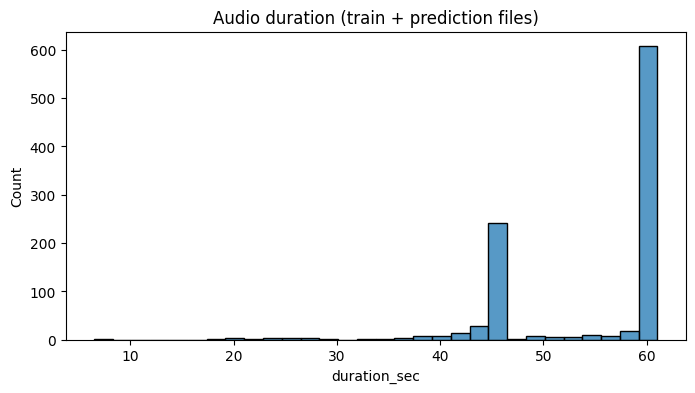

In [ ]:
# ============================================================
# 5. AUDIO VALIDATION (train + every file we must predict)
# ============================================================
def validate_audio(path):
    rec = {"readable": 0}
    try:
        info = sf.info(path)
        y_, _ = sf.read(path, dtype="float32", always_2d=False)
        if y_.ndim > 1:
            y_ = y_.mean(axis=1)
        rec.update(duration_sec=float(info.duration), sample_rate=int(info.samplerate),
                   channels=int(info.channels), nan_inf=int(not np.isfinite(y_).all()))
        y_ = np.nan_to_num(y_)
        rec["peak"] = float(np.max(np.abs(y_))) if len(y_) else 0.0
        rec["rms_db"] = float(20 * np.log10(np.sqrt(np.mean(y_ ** 2)) + 1e-9)) if len(y_) else -120.0
        rec["clip_ratio"] = float(np.mean(np.abs(y_) >= 0.999)) if len(y_) else 0.0
        rec["dc_offset"] = float(np.mean(y_)) if len(y_) else 0.0
        fr = librosa.feature.rms(y=y_, frame_length=1024, hop_length=512)[0] if len(y_) >= 1024 else np.array([0.0])
        rec["silence_frac_50db"] = float(np.mean(20 * np.log10(fr + 1e-9) < -50))
        rec["readable"] = 1
    except Exception as e:
        rec["error"] = str(e)[:80]
    with open(path, "rb") as f:
        rec["md5"] = hashlib.md5(f.read()).hexdigest()
    return rec


AUDIO_META = cached_table(
    "audio_validation.parquet", AUDIO_KEYS,
    lambda keys: parallel_rows(validate_audio, [KEY2PATH[k] for k in keys], "Validating audio"))

_train_set = set(train_keys)
AUDIO_META["role"] = ["train" if k in _train_set else "pred" for k in AUDIO_META.index]
AUDIO_META["flag_unreadable"] = (AUDIO_META["readable"] != 1)
AUDIO_META["flag_short"]      = AUDIO_META["duration_sec"] < 10
AUDIO_META["flag_near_silent"] = (AUDIO_META["rms_db"] < -50) | (AUDIO_META["silence_frac_50db"] > 0.95)
AUDIO_META["flag_clipped"]    = AUDIO_META["clip_ratio"] > 0.01
AUDIO_META["flag_not_16k"]    = AUDIO_META["sample_rate"] != TARGET_SR
AUDIO_META["flag_multichannel"] = AUDIO_META["channels"] > 1
flag_cols = [c for c in AUDIO_META.columns if c.startswith("flag_")]

print("Summary of audio properties:")
display(AUDIO_META[["duration_sec", "sample_rate", "channels", "peak", "rms_db",
                    "clip_ratio", "silence_frac_50db"]].describe().round(3))
print("\nFlag counts by role (a flag is a warning, files are NOT dropped):")
display(AUDIO_META.groupby("role")[flag_cols].sum())

md5_of = AUDIO_META["md5"].to_dict()
train_md5 = [md5_of[k] for k in train_keys]
dup_train = pd.Series(train_md5).duplicated(keep=False).sum()
pred_dup_train = sum(md5_of[k] in set(train_md5) for k in pred_keys)
print(f"\nTrain files sharing identical audio with another train file: {dup_train}")
print(f"Prediction files byte-identical to a labelled train file     : {pred_dup_train}")
if pred_dup_train:
    print("  -> these will still be predicted by the model, never copied from train labels.")

GROUPS = pd.factorize(pd.Series(train_md5))[0]

eda = pd.DataFrame({"label": y, "duration": AUDIO_META.loc[train_keys, "duration_sec"].values,
                    "near_silent": AUDIO_META.loc[train_keys, "flag_near_silent"].values})
print("\nCorrelation(label, duration):", round(eda[["label", "duration"]].corr().iloc[0, 1], 3))
print("\nLabel stats for near-silent train files:")
print(eda.groupby("near_silent")["label"].agg(["count", "mean", "std"]).round(3).to_string())
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(AUDIO_META["duration_sec"].dropna(), bins=30, ax=ax)
ax.set_title("Audio duration (train + prediction files)"); plt.show()

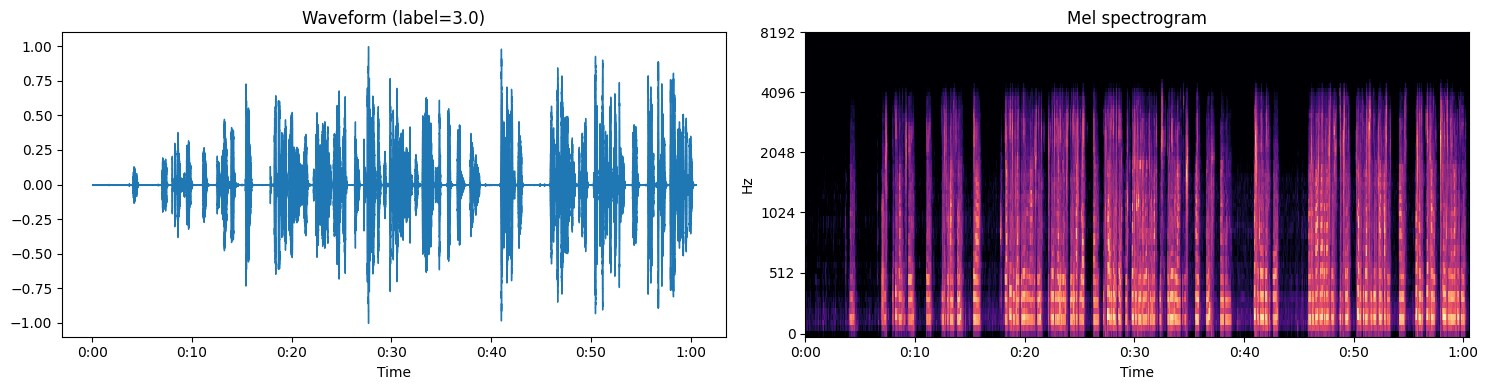

In [ ]:
# ============================================================
# 6. AUDIO PREPROCESSING
# ============================================================
def load_audio(path):
    y_, sr = librosa.load(str(path), sr=TARGET_SR, mono=True)
    y_ = y_.astype(np.float32)
    if len(y_):
        y_ = y_ - np.mean(y_)
        peak = np.max(np.abs(y_))
        if peak > 0:
            y_ = y_ / peak
    if len(y_) < TARGET_SR:
        y_ = np.pad(y_, (0, TARGET_SR - len(y_)))
    return y_, TARGET_SR


ex_path = KEY2PATH[train_keys[0]]
y_ex, sr_ex = load_audio(ex_path)
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
librosa.display.waveshow(y_ex, sr=sr_ex, ax=axes[0]); axes[0].set_title(f"Waveform (label={y[0]})")
S = librosa.power_to_db(librosa.feature.melspectrogram(y=y_ex, sr=sr_ex, n_mels=64), ref=np.max)
librosa.display.specshow(S, sr=sr_ex, x_axis="time", y_axis="mel", ax=axes[1]); axes[1].set_title("Mel spectrogram")
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# 7. ACOUSTIC / PROSODIC FEATURES
# ============================================================
def stats(x, prefix, which=("mean", "std", "p10", "p50", "p90")):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    out = {}
    for w in which:
        if len(x) == 0:
            out[f"{prefix}_{w}"] = np.nan
        elif w == "mean": out[f"{prefix}_{w}"] = float(np.mean(x))
        elif w == "std":  out[f"{prefix}_{w}"] = float(np.std(x))
        else:             out[f"{prefix}_{w}"] = float(np.percentile(x, int(w[1:])))
    return out


def acoustic_features(path):
    y_, sr = load_audio(path)
    out = {}
    dur = len(y_) / sr
    out["duration_sec"] = dur
    FL, HL = 1024, 512

    rms  = librosa.feature.rms(y=y_, frame_length=FL, hop_length=HL)[0]
    zcr  = librosa.feature.zero_crossing_rate(y_, frame_length=FL, hop_length=HL)[0]
    cent = librosa.feature.spectral_centroid(y=y_, sr=sr, n_fft=FL, hop_length=HL)[0]
    bw   = librosa.feature.spectral_bandwidth(y=y_, sr=sr, n_fft=FL, hop_length=HL)[0]
    roll = librosa.feature.spectral_rolloff(y=y_, sr=sr, n_fft=FL, hop_length=HL)[0]
    flat = librosa.feature.spectral_flatness(y=y_, n_fft=FL, hop_length=HL)[0]
    for arr, nm in [(rms, "rms"), (zcr, "zcr"), (cent, "centroid"), (bw, "bandwidth"),
                    (roll, "rolloff"), (flat, "flatness")]:
        out.update(stats(arr, nm))

    mfcc = librosa.feature.mfcc(y=y_, sr=sr, n_mfcc=20, n_fft=FL, hop_length=HL)
    d1 = librosa.feature.delta(mfcc)
    for i in range(20):
        out.update(stats(mfcc[i], f"mfcc{i+1}", ("mean", "std")))
    for i in range(13):
        out.update(stats(d1[i], f"mfccd{i+1}", ("std",)))

    try:
        con = librosa.feature.spectral_contrast(y=y_, sr=sr, n_fft=2048, hop_length=HL)
        for i in range(con.shape[0]):
            out.update(stats(con[i], f"contrast{i+1}", ("mean", "std")))
    except Exception:
        pass

    try:
        f0 = librosa.yin(y_, fmin=65, fmax=400, sr=sr, frame_length=2048, hop_length=HL)
        n = min(len(f0), len(rms))
        voiced = rms[:n] > np.percentile(rms, 30)
        f0v = f0[:n][voiced]
        out.update(stats(f0v, "f0", ("mean", "std", "p10", "p90")))
        out["f0_range"] = float(np.percentile(f0v, 90) - np.percentile(f0v, 10)) if len(f0v) else np.nan
        out["f0_delta_std"] = float(np.std(np.diff(f0v))) if len(f0v) > 2 else np.nan
    except Exception:
        pass

    iv = librosa.effects.split(y_, top_db=30, frame_length=FL, hop_length=HL)
    speech = sum(max(0, b - a) for a, b in iv) / len(y_)
    out["speech_ratio"] = speech
    out["n_segments"] = float(len(iv))
    out["segments_per_min"] = len(iv) / max(dur / 60.0, 1e-6)
    out["lead_silence"] = float(iv[0, 0] / sr) if len(iv) else dur
    out["trail_silence"] = float((len(y_) - iv[-1, 1]) / sr) if len(iv) else dur
    if len(iv) > 1:
        gaps = np.maximum((iv[1:, 0] - iv[:-1, 1]) / sr, 0)
        out.update(stats(gaps, "gap", ("mean", "std", "p50", "p90")))
        out["gap_n_075"] = float(np.sum(gaps >= 0.75))
        out["gap_n_150"] = float(np.sum(gaps >= 1.5))
        seg_len = (iv[:, 1] - iv[:, 0]) / sr
        out.update(stats(seg_len, "seglen", ("mean", "std", "p90")))
    else:
        out.update(stats([], "gap", ("mean", "std", "p50", "p90")))
        out["gap_n_075"] = out["gap_n_150"] = 0.0

    try:
        env = librosa.onset.onset_strength(y=y_, sr=sr, hop_length=HL)
        on = librosa.onset.onset_detect(onset_envelope=env, sr=sr, hop_length=HL)
        out["onsets_per_sec"] = len(on) / max(dur, 1e-6)
    except Exception:
        out["onsets_per_sec"] = np.nan
    out["dyn_range_rms"] = float(np.percentile(rms, 95) - np.percentile(rms, 5))
    return out


train_ac = cached_table("acoustic_v2.parquet", AUDIO_KEYS,
                        lambda keys: parallel_rows(acoustic_features, [KEY2PATH[k] for k in keys], "Acoustic"))
train_ac = train_ac.replace([np.inf, -np.inf], np.nan)
print("Acoustic feature table:", train_ac.shape)

[acoustic_v2.parquet] loaded from cache (985 files)
Acoustic feature table: (985, 120)


In [ ]:
# ============================================================
# 8. ASR (faster-whisper) - transcript + word timestamps + confidences
# ============================================================
ASR_CACHE = CACHE_DIR / f"asr_{ASR_MODEL_SIZE}.json"
ASR = json.load(open(ASR_CACHE, encoding="utf-8")) if ASR_CACHE.exists() else {}

ASR_PROMPT = "Umm, so, uh, I think that, like, you know... well, I mean, it was, uh, yeah." if ASR_KEEP_FILLERS else None

todo = [k for k in AUDIO_KEYS if k not in ASR]
if USE_ASR and todo:
    try:
        from faster_whisper import WhisperModel
        device = "cuda" if DEVICE == "cuda" else "cpu"
        asr_model = WhisperModel(ASR_MODEL_SIZE, device=device,
                                 compute_type="float16" if device == "cuda" else "int8")
        print(f"Whisper {ASR_MODEL_SIZE} on {device}; transcribing {len(todo)} files ...")

        def transcribe_key(k):
            y_, _ = load_audio(KEY2PATH[k])
            segs, info = asr_model.transcribe(
                y_, language="en", beam_size=5, word_timestamps=True,
                condition_on_previous_text=False, initial_prompt=ASR_PROMPT)
            segs = list(segs)
            return {
                "text": " ".join(s.text.strip() for s in segs).strip(),
                "words": [[w.word.strip(), round(w.start, 3), round(w.end, 3), round(w.probability, 4)]
                          for s in segs for w in (s.words or [])],
                "segs": [[s.avg_logprob, s.no_speech_prob, s.compression_ratio, s.start, s.end] for s in segs],
            }

        consecutive_fail = 0
        for i, k in enumerate(tqdm(todo, desc="ASR")):
            try:
                ASR[k] = transcribe_key(k)
                consecutive_fail = 0
            except Exception as e:
                consecutive_fail += 1
                print(f"ASR failed for {k}: {str(e)[:120]}")
                if consecutive_fail >= 3:
                    raise RuntimeError("ASR keeps failing - on Colab a cuDNN error is typical: "
                                       "pip install -q 'ctranslate2==4.4.0', restart the runtime, rerun. "
                                       f"Last error: {str(e)[:120]}")
            if (i + 1) % 50 == 0:
                json.dump(ASR, open(ASR_CACHE, "w", encoding="utf-8"))
        json.dump(ASR, open(ASR_CACHE, "w", encoding="utf-8"))
    except Exception as e:
        print(f"ASR unavailable ({str(e)[:150]}). Continuing without any transcript-based features.")

EMPTY_REC = {"text": "", "words": [], "segs": []}
ASR = {k: ASR.get(k, EMPTY_REC) for k in AUDIO_KEYS}
frac_ok = float(np.mean([bool(ASR[k]["text"]) for k in AUDIO_KEYS]))
ASR_READY = bool(USE_ASR) and frac_ok >= 0.9
TEXT = {k: ASR[k]["text"] for k in AUDIO_KEYS}
print(f"Files with a non-empty transcript: {frac_ok:.1%} | ASR ready: {ASR_READY}")
if USE_ASR and not ASR_READY:
    print("Too few transcripts -> transcript-based features are disabled for this run.")
if ASR_READY:
    for k in train_keys[:3]:
        print(f"\n[{k}] label={y[train_keys.index(k)]}\n{TEXT[k][:400]}")

Files with a non-empty transcript: 99.8% | ASR ready: True

[Dataset_Final/train/audio_192.wav] label=3.0
Well, this... the playground is very, very beautiful and fun. There are... there are playthings like the merry-go-round, the swing. The students usually enjoy this swing. It has to be like, um, it's more like a game of play. because once it's finished and the other person will have to finish, then the mirror goes around, which is fine for me. And most of them play for the ball. On some parks, whil

[Dataset_Final/train/audio_436.wav] label=3.0
The scene of a school playground, our playground looks like a very big playground, having a more and more greenery trees, in which way students like to garden a more trees to have a fresh air and all having a fresh oxygen, these, in the playground, these trees gives a very greenery view which will be very pleasant to our minds and will give relaxation. Where students like to like the play activiti

[Dataset_Final/train/audio_447.wav] label=3.

In [ ]:
# ============================================================
# 9. ASR-DERIVED FEATURES: timing / confidence / lexical / heuristic grammar
# ============================================================
def asr_timing_conf(rec, dur):
    words = [w for w in rec.get("words", []) if w[0]]
    n = len(words)
    f = {"asr_n_words": float(n), "asr_wpm": n / max(dur / 60.0, 1e-6)}
    if n == 0:
        return f
    st = np.array([w[1] for w in words]); en = np.array([w[2] for w in words]); pr = np.array([w[3] for w in words])
    wd = np.maximum(en - st, 0)
    f["asr_articulation_rate"] = n / max(wd.sum(), 1e-3)
    f["asr_first_word_start"] = float(st[0]); f["asr_tail_silence"] = float(max(dur - en[-1], 0))
    f["asr_speaking_span"] = float(en[-1] - st[0])
    gaps = np.maximum(st[1:] - en[:-1], 0) if n > 1 else np.array([])
    if len(gaps):
        f.update({"asr_gap_mean": gaps.mean(), "asr_gap_std": gaps.std(), "asr_gap_p90": np.percentile(gaps, 90),
                  "asr_gap_max": gaps.max(), "asr_gap_ratio": gaps.sum() / max(dur, 1e-6),
                  "asr_gaps_gt025_per100w": 100 * np.sum(gaps > 0.25) / n,
                  "asr_gaps_gt05_per100w": 100 * np.sum(gaps > 0.5) / n,
                  "asr_gaps_gt10_per100w": 100 * np.sum(gaps > 1.0) / n,
                  "asr_gaps_gt20": float(np.sum(gaps > 2.0))})
    f.update({"asr_wdur_mean": wd.mean(), "asr_wdur_std": wd.std(), "asr_long_words_ratio": float(np.mean(wd > 0.8)),
              "asr_prob_mean": pr.mean(), "asr_prob_std": pr.std(), "asr_prob_min": pr.min(),
              "asr_prob_p10": np.percentile(pr, 10), "asr_prob_p25": np.percentile(pr, 25),
              "asr_low_prob_ratio_05": float(np.mean(pr < 0.5)), "asr_low_prob_ratio_03": float(np.mean(pr < 0.3))})
    sg = np.array(rec.get("segs", []), dtype=float)
    if len(sg):
        f.update({"asr_avg_logprob_mean": sg[:, 0].mean(), "asr_avg_logprob_min": sg[:, 0].min(),
                  "asr_no_speech_mean": sg[:, 1].mean(), "asr_no_speech_max": sg[:, 1].max(),
                  "asr_compression_mean": sg[:, 2].mean(), "asr_compression_max": sg[:, 2].max(),
                  "asr_n_segments": float(len(sg))})
    return f


FILLERS = {"um", "umm", "uh", "uhh", "er", "erm", "ah", "hmm", "hm", "mm", "mhm"}
SUBORD = {"because", "although", "though", "while", "whereas", "since", "unless", "which", "whom", "whose",
          "whether", "if", "when", "after", "before", "until", "that", "who"}
CONNECT = {"however", "therefore", "moreover", "furthermore", "also", "but", "so", "then", "and", "or"}
HEUR = {
    "sv_3sg_plural_verb": r"\b(he|she|it)\s+(are|have|do|were)\b",
    "sv_plural_3sg_verb": r"\b(you|we|they)\s+(is|has|does|was)\b",
    "sv_i_wrong":         r"\bi\s+(is|has|does|are)\b",
    "a_before_vowel":     r"\ba\s+[aeiou]\w+",
    "an_before_consonant": r"\ban\s+[^aeiou\W]\w+",
    "modal_plus_past":    r"\b(did|didn't|does|doesn't|do|don't|can|could|will|would|should|must|to)\s+(went|saw|ate|took|came|made|gave|got|had|was|were|been)\b",
    "double_comparative": r"\b(more|most)\s+\w+(er|est)\b",
    "adjacent_repeat":    r"\b(\w+)\s+\1\b",
}


def split_sentences(text, min_words=3, max_words=45):
    sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if len(s.split()) >= min_words]
    out = []
    for s in sents:
        w = s.split()
        if len(w) > max_words:
            out += [" ".join(w[i:i + 30]) for i in range(0, len(w), 30)]
        else:
            out.append(s)
    if not out and len(text.split()) >= min_words:
        w = text.split()
        out = [" ".join(w[i:i + 30]) for i in range(0, len(w), 30)]
    return out


def text_features(text):
    low = text.lower()
    words = re.findall(r"[a-z']+", low)
    n = len(words)
    f = {"txt_n_chars": float(len(text))}
    if n == 0:
        return f
    sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    slen = np.array([len(s.split()) for s in sents]) if sents else np.array([n])
    cnt = Counter(words)
    first100 = words[:100]
    f.update({
        "txt_n_sentences": float(len(sents)), "txt_words_per_sentence": float(slen.mean()),
        "txt_sentence_len_std": float(slen.std()), "txt_sentence_len_max": float(slen.max()),
        "txt_short_sentence_ratio": float(np.mean(slen < 5)),
        "txt_unique_ratio": len(cnt) / n, "txt_ttr_first100": len(set(first100)) / max(len(first100), 1),
        "txt_hapax_ratio": sum(1 for c in cnt.values() if c == 1) / n,
        "txt_avg_word_len": float(np.mean([len(w) for w in words])),
        "txt_long_word_ratio": float(np.mean([len(w) >= 8 for w in words])),
        "txt_filler_ratio": sum(cnt[w] for w in FILLERS) / n,
        "txt_filler_count": float(sum(cnt[w] for w in FILLERS)),
        "txt_phrase_filler_ratio": sum(low.count(p) for p in ("you know", "i mean", "kind of", "sort of")) / n,
        "txt_like_ratio": cnt["like"] / n,
        "txt_subord_ratio": sum(cnt[w] for w in SUBORD) / n,
        "txt_connect_ratio": sum(cnt[w] for w in CONNECT) / n,
        "txt_contraction_ratio": len(re.findall(r"\b\w+'(s|t|re|ve|ll|d|m)\b", low)) / n,
        "txt_ed_ratio": sum(1 for w in words if w.endswith("ed") and len(w) > 3) / n,
        "txt_ing_ratio": sum(1 for w in words if w.endswith("ing") and len(w) > 4) / n,
        "txt_i_ratio": cnt["i"] / n,
        "txt_dash_or_ellipsis": float(text.count("...") + text.count("-")),
        "txt_comma_per_sentence": text.count(",") / max(len(sents), 1),
    })
    tot = 0
    for name, pat in HEUR.items():
        c = len(re.findall(pat, low))
        f[f"txt_h_{name}"] = float(c); tot += c if name != "adjacent_repeat" else 0
    f["txt_h_total_errors"] = float(tot)
    f["txt_h_errors_per100w"] = 100.0 * tot / n
    return f


rows_asr, rows_txt = [], []
if ASR_READY:
    for k in AUDIO_KEYS:
        dur = float(AUDIO_META.loc[k, "duration_sec"])
        rows_asr.append(asr_timing_conf(ASR[k], dur))
        rows_txt.append(text_features(TEXT[k]))
    asr_tbl = pd.DataFrame(rows_asr, index=AUDIO_KEYS)
    txt_tbl = pd.DataFrame(rows_txt, index=AUDIO_KEYS)
else:
    asr_tbl = pd.DataFrame(index=AUDIO_KEYS); txt_tbl = pd.DataFrame(index=AUDIO_KEYS)

print("ASR timing/conf features:", asr_tbl.shape, "| lexical/heuristic features:", txt_tbl.shape)
if ASR_READY:
    tmp = pd.concat([asr_tbl.loc[train_keys].reset_index(drop=True), txt_tbl.loc[train_keys].reset_index(drop=True)], axis=1)
    cors = tmp.apply(lambda c: c.corr(pd.Series(y))).dropna().sort_values(key=np.abs, ascending=False)
    print("\nTop-12 single-feature correlations with the label (train):")
    print(cors.head(12).round(3).to_string())

ASR timing/conf features: (985, 32) | lexical/heuristic features: (985, 33)

Top-12 single-feature correlations with the label (train):
asr_prob_p25             0.667
asr_prob_mean            0.652
asr_prob_p10             0.645
asr_low_prob_ratio_05   -0.601
asr_avg_logprob_mean     0.598
asr_prob_std            -0.546
asr_low_prob_ratio_03   -0.501
txt_n_chars              0.398
asr_avg_logprob_min      0.369
asr_n_words              0.341
asr_wpm                  0.297
txt_avg_word_len         0.260


In [ ]:
# ============================================================
# 10. GRAMMAR FEATURES FROM THE TRANSCRIPT
#     (a) CoLA acceptability  (b) GPT-2 fluency  (c) LanguageTool rule matches
# ============================================================
def _dev():
    return "cuda" if DEVICE == "cuda" else "cpu"

cola_tbl = pd.DataFrame(index=AUDIO_KEYS)
if ASR_READY and USE_COLA:
    try:
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
        _cola = {}

        def _cola_load():
            if not _cola:
                name = "textattack/roberta-base-CoLA"
                tok = AutoTokenizer.from_pretrained(name)
                mdl = AutoModelForSequenceClassification.from_pretrained(name).to(_dev()).eval()
                _cola.update(tok=tok, mdl=mdl, flip=False)

                p = _cola_prob(["She goes to school every day.", "She go to school every days yesterday the."])
                if p[0] < p[1]:
                    _cola["flip"] = True
                print(f"CoLA sanity check  good={p[0]:.3f}  bad={p[1]:.3f}  flipped={_cola['flip']}")

        @torch.no_grad()
        def _cola_prob(sents, bs=32):
            tok, mdl = _cola["tok"], _cola["mdl"]
            out = []
            for i in range(0, len(sents), bs):
                enc = tok(sents[i:i + bs], return_tensors="pt", padding=True, truncation=True, max_length=96).to(_dev())
                pr = torch.softmax(mdl(**enc).logits, -1)[:, 1]
                out += pr.cpu().tolist()
            p = np.array(out)
            return 1 - p if _cola.get("flip") else p

        def cola_rows(keys):
            _cola_load()
            rows = []
            for k in tqdm(keys, desc="CoLA"):
                s = split_sentences(TEXT[k])
                if not s:
                    rows.append({}); continue
                p = _cola_prob(s); w = np.array([len(x.split()) for x in s], dtype=float)
                rows.append({"cola_mean": p.mean(), "cola_wmean": float((p * w).sum() / w.sum()), "cola_min": p.min(),
                             "cola_p25": np.percentile(p, 25), "cola_median": np.median(p),
                             "cola_frac_lt05": float(np.mean(p < 0.5)), "cola_frac_lt02": float(np.mean(p < 0.2)),
                             "cola_n_sent": float(len(s))})
            return rows

        cola_tbl = cached_table("cola.parquet", AUDIO_KEYS, cola_rows)
    except Exception as e:
        print("CoLA features skipped:", str(e)[:200])
print("CoLA:", cola_tbl.shape)

lm_tbl = pd.DataFrame(index=AUDIO_KEYS)
if ASR_READY and USE_GPT2_LM:
    try:
        from transformers import AutoTokenizer, AutoModelForCausalLM
        _lm = {}

        @torch.no_grad()
        def _nll(sents, bs=16):
            tok, mdl = _lm["tok"], _lm["mdl"]
            res = []
            for i in range(0, len(sents), bs):
                batch = [tok.bos_token + s for s in sents[i:i + bs]]
                enc = tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=96).to(_dev())
                logits = mdl(**enc).logits[:, :-1].float()
                tgt = enc.input_ids[:, 1:]
                mask = enc.attention_mask[:, 1:].float()
                lp = torch.log_softmax(logits, -1).gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
                res += (-(lp * mask).sum(1) / mask.sum(1).clamp(min=1)).cpu().tolist()
            return np.array(res)

        def lm_rows(keys):
            if not _lm:
                tok = AutoTokenizer.from_pretrained("gpt2"); tok.pad_token = tok.eos_token
                _lm.update(tok=tok, mdl=AutoModelForCausalLM.from_pretrained("gpt2").to(_dev()).eval())
            rows = []
            for k in tqdm(keys, desc="GPT-2 NLL"):
                s = split_sentences(TEXT[k])
                if not s:
                    rows.append({}); continue
                v = _nll(s)
                rows.append({"lm_nll_mean": v.mean(), "lm_nll_std": v.std(), "lm_nll_p75": np.percentile(v, 75),
                             "lm_nll_p90": np.percentile(v, 90), "lm_nll_max": v.max(),
                             "lm_ppl_median": float(np.exp(np.median(v)))})
            return rows

        lm_tbl = cached_table("gpt2_lm.parquet", AUDIO_KEYS, lm_rows)
    except Exception as e:
        print("GPT-2 features skipped:", str(e)[:200])
print("GPT-2 LM:", lm_tbl.shape)

lt_tbl = pd.DataFrame(index=AUDIO_KEYS)
if ASR_READY and USE_LANGUAGETOOL:
    try:
        import language_tool_python
        _lt = {}
        LT_KEYS = {"agree": ["AGREEMENT", "SUBJECT_VERB", "NON3PRS", "PRONOUN"], "verb": ["VERB", "TENSE", "PAST", "PARTICIPLE", "MODAL"],
                   "article": ["ARTICLE", "A_VS_AN", "DET_", "DT_"], "plural": ["PLURAL", "NNS", "SINGULAR"],
                   "prep": ["PREP", "IN_ON", "TO_WITH"], "order": ["ORDER", "WORD_ORDER"], "conf": ["CONFUS", "HOMOPHONE", "THEIR_THERE"]}

        def lt_rows(keys):
            if not _lt:
                _lt["tool"] = language_tool_python.LanguageTool("en-US")
            rows = []
            for k in tqdm(keys, desc="LanguageTool"):
                t = TEXT[k]; n = max(len(t.split()), 1)
                if n < 3:
                    rows.append({}); continue
                ms = _lt["tool"].check(t)
                cats = Counter((getattr(m, "category", "") or "").upper() for m in ms)
                rid = [((getattr(m, "ruleId", None) or getattr(m, "rule_id", None) or "")).upper() for m in ms]
                core = sum(v for c, v in cats.items() if c not in {"PUNCTUATION", "CASING", "TYPOGRAPHY", "STYLE", "REDUNDANCY"})
                r = {"lt_total_per100w": 100 * len(ms) / n, "lt_core_per100w": 100 * core / n,
                     "lt_grammar_per100w": 100 * cats.get("GRAMMAR", 0) / n, "lt_typos_per100w": 100 * cats.get("TYPOS", 0) / n,
                     "lt_style_per100w": 100 * cats.get("STYLE", 0) / n, "lt_total": float(len(ms)), "lt_core": float(core)}
                for g, kws in LT_KEYS.items():
                    r[f"lt_{g}_per100w"] = 100 * sum(any(kw in x for kw in kws) for x in rid) / n
                rows.append(r)
            return rows

        lt_tbl = cached_table("languagetool.parquet", AUDIO_KEYS, lt_rows)
        if "tool" in _lt:
            _lt["tool"].close()
    except Exception as e:
        print("LanguageTool features skipped (Java / download problem?):", str(e)[:200])
print("LanguageTool:", lt_tbl.shape)

[cola.parquet] loaded from cache (985 files)
CoLA: (985, 8)
[gpt2_lm.parquet] loaded from cache (985 files)
GPT-2 LM: (985, 6)
[languagetool.parquet] loaded from cache (985 files)
LanguageTool: (985, 14)


In [ ]:
# ============================================================
# 11. PRETRAINED EMBEDDINGS: SSL audio models + transcript sentence embeddings
# ============================================================
SSL_EMB = {}

if USE_SSL and torch is not None:
    try:
        from transformers import AutoFeatureExtractor, AutoModel
        _ssl_ok = True
    except Exception as e:
        print("transformers unavailable, SSL embeddings skipped:", str(e)[:150]); _ssl_ok = False
    for mname in (SSL_MODELS if _ssl_ok else []):
        try:
            short = mname.split("/")[-1]

            def ssl_compute(keys, mname=mname):
                ext = AutoFeatureExtractor.from_pretrained(mname)
                mdl = AutoModel.from_pretrained(mname).to(_dev()).eval()
                outs = []
                with torch.no_grad():
                    for k in tqdm(keys, desc=f"SSL {short}"):
                        y_, _ = load_audio(KEY2PATH[k])
                        inp = ext(y_, sampling_rate=TARGET_SR, return_tensors="pt")
                        hs = mdl(inp["input_values"].to(_dev()), output_hidden_states=True).hidden_states
                        hs = torch.stack(hs)[:, 0].float()
                        outs.append(torch.stack([hs.mean(1), hs.std(1)]).cpu().numpy())
                return outs

            SSL_EMB[mname] = cached_array(f"ssl_{short}.npz", AUDIO_KEYS, ssl_compute)
            print(mname, SSL_EMB[mname].shape)
        except Exception as e:
            print(f"SSL model {mname} skipped:", str(e)[:200])

TXT_EMB = None
if ASR_READY and USE_TEXT_EMB:
    try:
        from sentence_transformers import SentenceTransformer

        def txt_compute(keys):
            st = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=_dev())
            return st.encode([TEXT[k] for k in keys], batch_size=16, show_progress_bar=True, normalize_embeddings=True)

        TXT_EMB = cached_array("txt_mpnet.npz", AUDIO_KEYS, txt_compute)
        print("Transcript embeddings:", TXT_EMB.shape)
    except Exception as e:
        print("Text embeddings skipped:", str(e)[:200])

[ssl_wavlm-base-plus.npz] loaded from cache (985 files)
microsoft/wavlm-base-plus (985, 2, 13, 768)
[ssl_wav2vec2-base-960h.npz] loaded from cache (985 files)
facebook/wav2vec2-base-960h (985, 2, 13, 768)
[txt_mpnet.npz] loaded from cache (985 files)
Transcript embeddings: (985, 768)


In [ ]:
# ============================================================
# 12. ASSEMBLE FEATURE GROUPS + QUALITY CHECKS
# ============================================================
FEATURE_GROUPS = {
    "acoustic":    train_ac,
    "asr_timing":  asr_tbl,
    "text_lexical": txt_tbl,
    "grammar_cola": cola_tbl,
    "grammar_lm":  lm_tbl,
    "grammar_lt":  lt_tbl,
}
FEATURE_GROUPS = {g: d for g, d in FEATURE_GROUPS.items() if d.shape[1] > 0}

X_all = pd.concat(FEATURE_GROUPS.values(), axis=1)
X_all = X_all.loc[:, ~X_all.columns.duplicated()]
GROUP_OF = {c: g for g, d in FEATURE_GROUPS.items() for c in d.columns}

tr_part = X_all.loc[train_keys]
keep = [c for c in X_all.columns if tr_part[c].notna().mean() > 0.5 and tr_part[c].nunique(dropna=True) > 1]
dropped = len(X_all.columns) - len(keep)
X_all = X_all[keep]
HAND_COLS = list(X_all.columns)
GROUP_COLS = {g: [c for c in HAND_COLS if GROUP_OF[c] == g] for g in FEATURE_GROUPS}

print(f"Hand-crafted feature matrix: {X_all.shape[1]} columns ({dropped} constant/empty dropped)")
for g, cols in GROUP_COLS.items():
    print(f"  {g:14s}: {len(cols)}")

only_pred = [k for k in pred_keys if k not in set(train_keys)]
if HAS_LGBM and len(only_pred) >= 30:
    from sklearn.model_selection import cross_val_predict, StratifiedKFold
    from sklearn.metrics import roc_auc_score
    from lightgbm import LGBMClassifier
    Xa = pd.concat([X_all.loc[train_keys], X_all.loc[only_pred]]).values
    ya = np.r_[np.zeros(len(train_keys)), np.ones(len(only_pred))]
    pa = cross_val_predict(LGBMClassifier(n_estimators=150, learning_rate=0.05, num_leaves=8, verbose=-1, random_state=SEED),
                           Xa, ya, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method="predict_proba")[:, 1]
    print(f"\nAdversarial validation AUC (train vs prediction files): {roc_auc_score(ya, pa):.3f}  (0.5 = same distribution)")
else:
    print("\nAdversarial validation skipped (prediction files overlap train, or too few).")

Hand-crafted feature matrix: 210 columns (3 constant/empty dropped)
  acoustic      : 120
  asr_timing    : 32
  text_lexical  : 31
  grammar_cola  : 8
  grammar_lm    : 6
  grammar_lt    : 13

Adversarial validation AUC (train vs prediction files): 0.825  (0.5 = same distribution)


In [ ]:
# ============================================================
# 13. LEAKAGE-FREE VALIDATION SETUP
# ============================================================
STRAT = np.clip(np.round(y).astype(int), 0, 5)


def make_folds(seed):
    sk = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    return list(sk.split(np.zeros(len(y)), STRAT, GROUPS))


FOLD_SETS = [make_folds(SEED + 17 * r) for r in range(N_REPEATS)]


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


def pear(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return 0.0 if a.std() == 0 or b.std() == 0 else float(pearsonr(a, b)[0])


def run_cv(factory, X, fold_sets=None):
    """Returns out-of-fold predictions, shape (n_repeats, n_samples). Everything fitted inside the fold."""
    fold_sets = fold_sets or FOLD_SETS
    runs = np.zeros((len(fold_sets), len(y)))
    for r, folds in enumerate(fold_sets):
        for tr, va in folds:
            m = factory(X.shape[1])
            m.fit(X[tr], y[tr])
            runs[r, va] = m.predict(X[va])
    return runs


def summarize(runs):
    """mean over repeats of (RMSE, Pearson) on clipped predictions"""
    return (float(np.mean([rmse(y, np.clip(r, 0, 5)) for r in runs])),
            float(np.mean([pear(y, r) for r in runs])))


def f_ridge_sel(k=200):
    def f(d):
        return Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                         ("sel", SelectKBest(f_regression, k=min(k, d))),
                         ("m", RidgeCV(alphas=np.logspace(-1, 4, 16)))])
    return f


def f_svr_sel(k=80):
    def f(d):
        return Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                         ("sel", SelectKBest(f_regression, k=min(k, d))),
                         ("m", GridSearchCV(SVR(kernel="rbf", gamma="scale"),
                                            {"C": [0.5, 2, 8], "epsilon": [0.1, 0.3]}, cv=3,
                                            scoring="neg_root_mean_squared_error"))])
    return f


def f_et(d):
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("m", ExtraTreesRegressor(n_estimators=500, min_samples_leaf=2, max_features=0.4,
                                               n_jobs=-1, random_state=SEED))])


def _gbm():
    if HAS_LGBM:
        return LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=12, min_child_samples=15,
                             subsample=0.8, subsample_freq=1, colsample_bytree=0.5, reg_lambda=5.0,
                             n_jobs=-1, random_state=SEED, verbose=-1)
    return HistGradientBoostingRegressor(max_iter=300, learning_rate=0.03, max_leaf_nodes=12,
                                         l2_regularization=3.0, random_state=SEED)


def f_gbm(d):
    return Pipeline([("m", _gbm())])


def f_emb_ridge(d):
    return Pipeline([("sc", StandardScaler()), ("m", RidgeCV(alphas=np.logspace(1, 5, 12)))])


def f_emb_svr(d):
    return Pipeline([("sc", StandardScaler()), ("pca", PCA(n_components=min(64, d), random_state=SEED)),
                     ("m", GridSearchCV(SVR(kernel="rbf", gamma="scale"),
                                        {"C": [0.5, 2, 8], "epsilon": [0.1, 0.3]}, cv=3,
                                        scoring="neg_root_mean_squared_error"))])


print(f"{N_REPEATS} x {N_FOLDS}-fold StratifiedGroupKFold ready | label-mean baseline RMSE = {y.std():.4f}")

2 x 5-fold StratifiedGroupKFold ready | label-mean baseline RMSE = 1.2382


In [ ]:
# ============================================================
# 14. FEATURE-GROUP ABLATION (proper this time: every group is evaluated)
# ============================================================
def f_et_fast(d):
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("m", ExtraTreesRegressor(n_estimators=250, min_samples_leaf=2, max_features=0.5,
                                               n_jobs=-1, random_state=SEED))])

abl_rows, cum = [], []
for g, cols in GROUP_COLS.items():
    Xg = X_all.loc[train_keys, cols].values
    r, p = summarize(run_cv(f_et_fast, Xg, FOLD_SETS[:1]))
    abl_rows.append({"feature_set": f"only: {g}", "n_feat": len(cols), "RMSE": r, "Pearson": p})
for g, cols in GROUP_COLS.items():
    cum += cols
    Xg = X_all.loc[train_keys, cum].values
    r, p = summarize(run_cv(f_et_fast, Xg, FOLD_SETS[:1]))
    abl_rows.append({"feature_set": f"cumulative up to: {g}", "n_feat": len(cum), "RMSE": r, "Pearson": p})

ablation_df = pd.DataFrame(abl_rows)
display(ablation_df.round(4))
print("Old notebook baseline (acoustic only, Ridge): RMSE 0.8202 / Pearson 0.750; best old model (HGB): RMSE 0.7765 / Pearson 0.779")

,feature_set,n_feat,RMSE,Pearson
0,only: acoustic,120,0.7415,0.8043
1,only: asr_timing,32,0.7934,0.7686
2,only: text_lexical,31,1.0678,0.5071
3,only: grammar_cola,8,1.1286,0.4282
4,only: grammar_lm,6,1.2029,0.2611
5,only: grammar_lt,13,1.2195,0.2262
6,cumulative up to: acoustic,120,0.7415,0.8043
7,cumulative up to: asr_timing,152,0.6492,0.8547
8,cumulative up to: text_lexical,183,0.6371,0.8610
9,cumulative up to: grammar_cola,191,0.6505,0.8532


Old notebook baseline (acoustic only, Ridge): RMSE 0.8202 / Pearson 0.750; best old model (HGB): RMSE 0.7765 / Pearson 0.779


microsoft/wavlm-base-plus: layer-wise Ridge RMSE = [0.727, 0.682, 0.635, 0.642, 0.612, 0.602, 0.581, 0.565, 0.564, 0.565, 0.564, 0.566, 0.586]
  -> using layers [7, 8, 10]


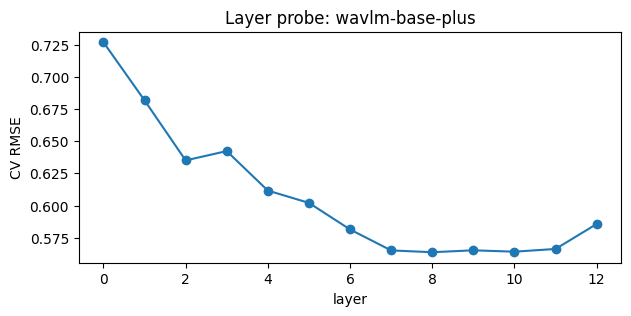

facebook/wav2vec2-base-960h: layer-wise Ridge RMSE = [0.708, 0.675, 0.656, 0.628, 0.624, 0.625, 0.618, 0.616, 0.601, 0.599, 0.613, 0.644, 0.694]
  -> using layers [8, 9, 10]


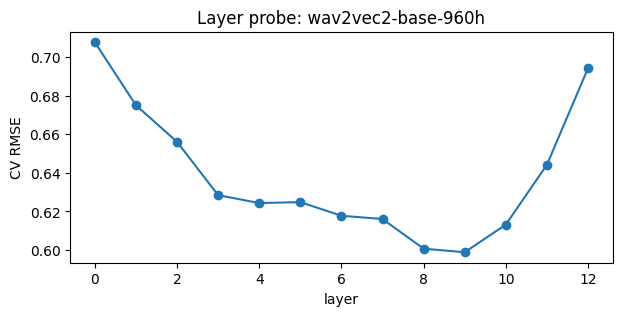

ridge_hand                   RMSE 0.6485  Pearson 0.8410   (0s)
svr_hand                     RMSE 0.6687  Pearson 0.8406   (4s)
et_hand                      RMSE 0.6517  Pearson 0.8529   (31s)
gbm_hand                     RMSE 0.6249  Pearson 0.8636   (17s)
ridge_wavlm-base-plus        RMSE 0.5366  Pearson 0.8999   (3s)
svr_wavlm-base-plus          RMSE 0.5680  Pearson 0.8876   (10s)
gbm_hybrid_wavlm-base-plus   RMSE 0.5760  Pearson 0.8858   (31s)
ridge_wav2vec2-base-960h     RMSE 0.5877  Pearson 0.8784   (5s)
svr_wav2vec2-base-960h       RMSE 0.6047  Pearson 0.8729   (8s)
gbm_hybrid_wav2vec2-base-960h RMSE 0.5826  Pearson 0.8828   (30s)
ridge_txtemb                 RMSE 0.9643  Pearson 0.6273   (2s)
svr_txtemb                   RMSE 0.9604  Pearson 0.6336   (6s)


,model,matrix,n_feat,RMSE,Pearson,sec
0,ridge_wavlm-base-plus,ssl:wavlm-base-plus,4608,0.5366,0.8999,3.3
1,svr_wavlm-base-plus,ssl:wavlm-base-plus,4608,0.5680,0.8876,9.8
2,gbm_hybrid_wavlm-base-plus,hand+ssl:wavlm-base-plus,4818,0.5760,0.8858,31.1
3,gbm_hybrid_wav2vec2-base-960h,hand+ssl:wav2vec2-base-960h,4818,0.5826,0.8828,29.6
4,ridge_wav2vec2-base-960h,ssl:wav2vec2-base-960h,4608,0.5877,0.8784,5.3
5,svr_wav2vec2-base-960h,ssl:wav2vec2-base-960h,4608,0.6047,0.8729,8.2
6,gbm_hand,hand,210,0.6249,0.8636,17.2
7,ridge_hand,hand,210,0.6485,0.8410,0.4
8,et_hand,hand,210,0.6517,0.8529,30.9
9,svr_hand,hand,210,0.6687,0.8406,4.5


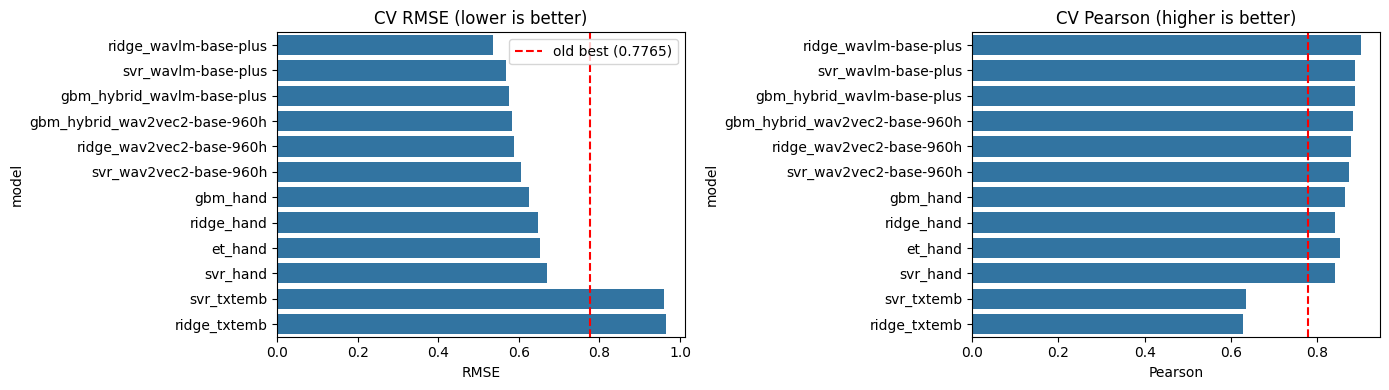

In [ ]:
# ============================================================
# 15. BUILD MATRICES + SSL LAYER PROBE + MODEL COMPARISON
# ============================================================
MATS = {}
MATS["hand"] = (X_all.loc[train_keys].values, X_all.loc[pred_keys].values)
tr_idx = [KEY_IDX[k] for k in train_keys]
pr_idx = [KEY_IDX[k] for k in pred_keys]

SSL_CHOICE = {}
for mname, arr in SSL_EMB.items():
    n_layers = arr.shape[2]
    scores = []
    for L in range(n_layers):
        XL = np.concatenate([arr[tr_idx, 0, L], arr[tr_idx, 1, L]], axis=1)
        scores.append(summarize(run_cv(f_emb_ridge, XL, FOLD_SETS[:1]))[0])
    best = list(np.argsort(scores)[:3])
    SSL_CHOICE[mname] = sorted(int(b) for b in best)
    print(f"{mname}: layer-wise Ridge RMSE = {np.round(scores, 3).tolist()}\n  -> using layers {SSL_CHOICE[mname]}")
    plt.figure(figsize=(7, 3)); plt.plot(scores, marker="o"); plt.title(f"Layer probe: {mname.split('/')[-1]}")
    plt.xlabel("layer"); plt.ylabel("CV RMSE"); plt.show()
    sel = SSL_CHOICE[mname]
    short = mname.split("/")[-1]
    feat = lambda idx: np.concatenate([np.concatenate([arr[idx, 0, L], arr[idx, 1, L]], axis=1) for L in sel], axis=1)
    MATS[f"ssl:{short}"] = (feat(tr_idx), feat(pr_idx))


if TXT_EMB is not None:
    MATS["txt"] = (TXT_EMB[tr_idx], TXT_EMB[pr_idx])

SPECS = [("ridge_hand", f_ridge_sel(200), "hand"),
         ("svr_hand",   f_svr_sel(80),    "hand"),
         ("et_hand",    f_et,             "hand"),
         ("gbm_hand",   f_gbm,            "hand")]
for key in [k for k in MATS if k.startswith("ssl:")]:
    short = key.split(":")[1]
    SPECS += [(f"ridge_{short}", f_emb_ridge, key), (f"svr_{short}", f_emb_svr, key)]

    nh, ne = MATS["hand"][0].shape[1], MATS[key][0].shape[1]
    MATS[f"hand+{key}"] = (np.hstack([MATS["hand"][0], MATS[key][0]]), np.hstack([MATS["hand"][1], MATS[key][1]]))

    def f_hybrid(d, nh=nh):
        ct = ColumnTransformer([("h", "passthrough", list(range(nh))),
                                ("e", Pipeline([("sc", StandardScaler()), ("pca", PCA(32, random_state=SEED))]),
                                 list(range(nh, d)))])
        return Pipeline([("ct", ct), ("m", _gbm())])
    SPECS.append((f"gbm_hybrid_{short}", f_hybrid, f"hand+{key}"))
if "txt" in MATS:
    SPECS.append(("ridge_txtemb", f_emb_ridge, "txt"))
    SPECS.append(("svr_txtemb", f_emb_svr, "txt"))

OOF, RESULTS = {}, []
for name, fac, mk in SPECS:
    t0 = time.time()
    runs = run_cv(fac, MATS[mk][0])
    OOF[name] = runs
    r, p = summarize(runs)
    RESULTS.append({"model": name, "matrix": mk, "n_feat": MATS[mk][0].shape[1], "RMSE": r, "Pearson": p,
                    "sec": round(time.time() - t0, 1)})
    print(f"{name:28s} RMSE {r:.4f}  Pearson {p:.4f}   ({time.time()-t0:.0f}s)")

results_df = pd.DataFrame(RESULTS).sort_values("RMSE").reset_index(drop=True)
display(results_df.round(4))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=results_df, y="model", x="RMSE", ax=axes[0]); axes[0].axvline(0.7765, ls="--", c="r", label="old best (0.7765)")
axes[0].legend(); axes[0].set_title("CV RMSE (lower is better)")
sns.barplot(data=results_df, y="model", x="Pearson", ax=axes[1]); axes[1].axvline(0.779, ls="--", c="r")
axes[1].set_title("CV Pearson (higher is better)")
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# 16. BLENDING / STACKING + VALIDATION-BASED SELECTION
# ============================================================
names = list(OOF.keys())
P = np.column_stack([OOF[n].mean(axis=0) for n in names])
order = np.argsort([results_df.set_index("model").loc[n, "RMSE"] for n in names])

print("Correlation between base-model OOF predictions:")
display(pd.DataFrame(P, columns=names).corr().round(2))

STACK_FOLDS = [make_folds(SEED + 1000 + 31 * r) for r in range(N_REPEATS)]


def stack_cv(cols, positive=True):
    runs = np.zeros((len(STACK_FOLDS), len(y)))
    for r, folds in enumerate(STACK_FOLDS):
        for tr, va in folds:
            lr = LinearRegression(positive=positive).fit(P[tr][:, cols], y[tr])
            runs[r, va] = lr.predict(P[va][:, cols])
    return runs

candidates = {}
best_single = int(order[0])
candidates[f"single: {names[best_single]}"] = ("single", [best_single], P[:, best_single][None, :])
for k in (3, 5, len(names)):
    cols = [int(i) for i in order[:min(k, len(names))]]
    if len(cols) > 1:
        candidates[f"mean of top-{len(cols)}"] = ("mean", cols, P[:, cols].mean(axis=1)[None, :])
candidates["NNLS stack (all models)"] = ("stack", list(range(len(names))), stack_cv(list(range(len(names)))))
top_cols = [int(i) for i in order[:min(6, len(names))]]
candidates["NNLS stack (top-6)"] = ("stack", top_cols, stack_cv(top_cols))

cand_rows = []
for cname, (kind, cols, runs) in candidates.items():
    r, p = summarize(runs)
    cand_rows.append({"strategy": cname, "RMSE": r, "Pearson": p})
cand_df = pd.DataFrame(cand_rows).sort_values("RMSE").reset_index(drop=True)
display(cand_df.round(4))

SELECTED = cand_df.loc[0, "strategy"]
SEL_KIND, SEL_COLS, SEL_RUNS = candidates[SELECTED]
SEL_NAMES = [names[i] for i in SEL_COLS]
SELECTED_OOF = SEL_RUNS.mean(axis=0)

if SEL_KIND == "stack":
    final_lr = LinearRegression(positive=True).fit(P[:, SEL_COLS], y)
    SEL_WEIGHTS, SEL_INTERCEPT = final_lr.coef_, float(final_lr.intercept_)
    print("\nStack weights:", {n: round(float(w), 3) for n, w in zip(SEL_NAMES, SEL_WEIGHTS) if w > 1e-6},
          "| intercept", round(SEL_INTERCEPT, 3))
elif SEL_KIND == "mean":
    SEL_WEIGHTS, SEL_INTERCEPT = np.ones(len(SEL_COLS)) / len(SEL_COLS), 0.0
else:
    SEL_WEIGHTS, SEL_INTERCEPT = np.ones(1), 0.0

sel_rmse, sel_pear = summarize(SEL_RUNS)
print(f"\nSELECTED: {SELECTED}\n  validation RMSE {sel_rmse:.4f} | Pearson {sel_pear:.4f}"
      f"   (old notebook: 0.7765 / 0.779)")

oof_clip = np.clip(SELECTED_OOF, 0, 5)
oof_half = np.clip(np.round(SELECTED_OOF * 2) / 2, 0, 5)
print(f"Post-processing  clip only: RMSE {rmse(y, oof_clip):.4f} | round-to-0.5: RMSE {rmse(y, oof_half):.4f}")
ROUND_HALF = rmse(y, oof_half) < rmse(y, oof_clip) - 0.002
print("Rounding to 0.5 steps will be", "APPLIED" if ROUND_HALF else "NOT applied", "(only used if it clearly lowers OOF RMSE)")

Correlation between base-model OOF predictions:


,ridge_hand,svr_hand,et_hand,gbm_hand,ridge_wavlm-base-plus,svr_wavlm-base-plus,gbm_hybrid_wavlm-base-plus,ridge_wav2vec2-base-960h,svr_wav2vec2-base-960h,gbm_hybrid_wav2vec2-base-960h,ridge_txtemb,svr_txtemb
ridge_hand,1.00,0.90,0.93,0.95,0.87,0.87,0.94,0.87,0.86,0.93,0.64,0.65
svr_hand,0.90,1.00,0.95,0.95,0.88,0.88,0.94,0.87,0.87,0.94,0.60,0.61
et_hand,0.93,0.95,1.00,0.98,0.90,0.90,0.97,0.90,0.89,0.96,0.61,0.61
gbm_hand,0.95,0.95,0.98,1.00,0.91,0.91,0.99,0.91,0.90,0.98,0.63,0.64
ridge_wavlm-base-plus,0.87,0.88,0.90,0.91,1.00,0.98,0.94,0.96,0.95,0.93,0.62,0.64
svr_wavlm-base-plus,0.87,0.88,0.90,0.91,0.98,1.00,0.94,0.95,0.96,0.94,0.61,0.63
gbm_hybrid_wavlm-base-plus,0.94,0.94,0.97,0.99,0.94,0.94,1.00,0.93,0.93,0.99,0.64,0.65
ridge_wav2vec2-base-960h,0.87,0.87,0.90,0.91,0.96,0.95,0.93,1.00,0.97,0.94,0.62,0.63
svr_wav2vec2-base-960h,0.86,0.87,0.89,0.90,0.95,0.96,0.93,0.97,1.00,0.94,0.61,0.62
gbm_hybrid_wav2vec2-base-960h,0.93,0.94,0.96,0.98,0.93,0.94,0.99,0.94,0.94,1.00,0.64,0.64


,strategy,RMSE,Pearson
0,NNLS stack (all models),0.5030,0.9121
1,NNLS stack (top-6),0.5106,0.9096
2,mean of top-3,0.5204,0.9082
3,mean of top-5,0.5221,0.9080
4,single: ridge_wavlm-base-plus,0.5321,0.9017
5,mean of top-12,0.5527,0.9063



Stack weights: {'ridge_hand': 0.089, 'svr_hand': 0.108, 'ridge_wavlm-base-plus': 0.556, 'svr_wavlm-base-plus': 0.024, 'gbm_hybrid_wavlm-base-plus': 0.091, 'ridge_wav2vec2-base-960h': 0.008, 'svr_wav2vec2-base-960h': 0.057, 'gbm_hybrid_wav2vec2-base-960h': 0.066, 'ridge_txtemb': 0.093, 'svr_txtemb': 0.047} | intercept -0.464

SELECTED: NNLS stack (all models)
  validation RMSE 0.5030 | Pearson 0.9121   (old notebook: 0.7765 / 0.779)
Post-processing  clip only: RMSE 0.5028 | round-to-0.5: RMSE 0.5275
Rounding to 0.5 steps will be NOT applied (only used if it clearly lowers OOF RMSE)


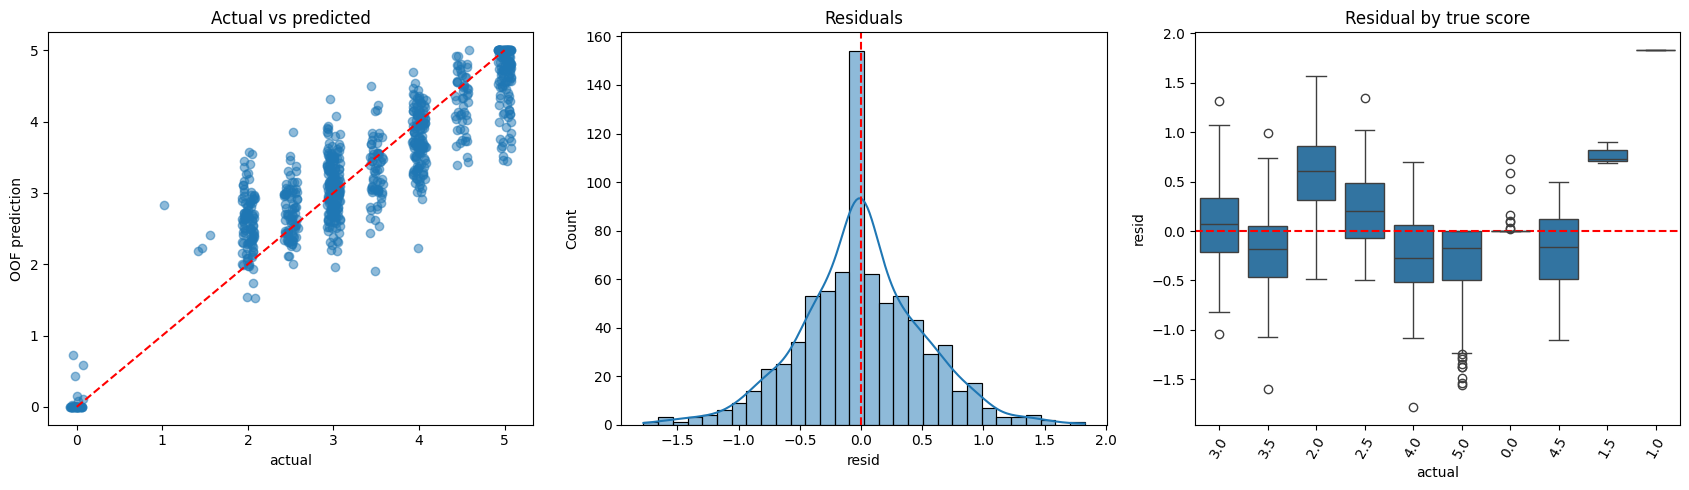

Error by true-score band:


,count,mean,median
band,,,
<=1,38,0.104,0.000
"(1,2]",105,0.616,0.627
"(2,3]",253,0.325,0.264
"(3,4]",188,0.381,0.328
"(4,5]",185,0.344,0.223


Slope of prediction vs truth = 0.81  (<1 means predictions are squeezed toward the mean)

Mean |error| by duration quartile:
duration
(20.058999999999997, 54.187]    0.436
(54.187, 60.075]                0.347
(60.075, 61.04]                 0.363

Mean |error| by n_words quartile:
n_words
(-0.001, 83.0]    0.401
(83.0, 103.0]     0.387
(103.0, 122.0]    0.369
(122.0, 154.0]    0.331

Mean |error| by asr_conf quartile:
asr_conf
(0.0393, 0.836]    0.365
(0.836, 0.885]     0.447
(0.885, 0.919]     0.404
(0.919, 0.988]     0.276

Worst 12 validation errors:
  actual=1.0 pred=2.83 | Dataset_Final/train/audio_108.wav | As a young child, one of the most exacting places to be was the playground. It was a place where the rules of classrooms and the structure environment of school
  actual=4.0 pred=2.22 | Dataset_Final/train/audio_238.wav | Playground has many children. There are many... there are slides, see-saw, and different kind of playing activities. The noise from the playground are comin

In [ ]:
# ============================================================
# 17. ERROR ANALYSIS (out-of-fold predictions only)
# ============================================================
pred_oof = np.clip(SELECTED_OOF, 0, 5)
err = pd.DataFrame({"key": train_keys, "actual": y, "pred": pred_oof})
err["resid"] = err["pred"] - err["actual"]; err["abs_err"] = err["resid"].abs()
err["duration"] = AUDIO_META.loc[train_keys, "duration_sec"].values
if ASR_READY:
    err["n_words"] = [asr_tbl.loc[k, "asr_n_words"] for k in train_keys]
    err["asr_conf"] = [asr_tbl.loc[k, "asr_prob_mean"] if "asr_prob_mean" in asr_tbl else np.nan for k in train_keys]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].scatter(err.actual + np.random.uniform(-.08, .08, len(err)), err.pred, alpha=.5)
axes[0].plot([0, 5], [0, 5], "r--"); axes[0].set_xlabel("actual"); axes[0].set_ylabel("OOF prediction"); axes[0].set_title("Actual vs predicted")
sns.histplot(err.resid, bins=30, kde=True, ax=axes[1]); axes[1].axvline(0, c="r", ls="--"); axes[1].set_title("Residuals")
sns.boxplot(data=err, x=err.actual.round(1).astype(str), y="resid", ax=axes[2]); axes[2].axhline(0, c="r", ls="--")
axes[2].set_title("Residual by true score"); axes[2].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

err["band"] = pd.cut(err.actual, [-.01, 1, 2, 3, 4, 5.01], labels=["<=1", "(1,2]", "(2,3]", "(3,4]", "(4,5]"])
print("Error by true-score band:")
display(err.groupby("band", observed=True)["abs_err"].agg(["count", "mean", "median"]).round(3))
slope = np.polyfit(err.actual, err.pred, 1)[0]
print(f"Slope of prediction vs truth = {slope:.2f}  (<1 means predictions are squeezed toward the mean)")

for col in [c for c in ["duration", "n_words", "asr_conf"] if c in err]:
    q = pd.qcut(err[col], 4, duplicates="drop")
    print(f"\nMean |error| by {col} quartile:")
    print(err.groupby(q, observed=True)["abs_err"].mean().round(3).to_string())

print("\nWorst 12 validation errors:")
worst = err.sort_values("abs_err", ascending=False).head(12)
for _, r in worst.iterrows():
    snippet = TEXT[r.key][:160].replace("\n", " ") if ASR_READY else ""
    print(f"  actual={r.actual:.1f} pred={r.pred:.2f} | {r.key} | {snippet}")

resid_cor = X_all.loc[train_keys].apply(lambda c: c.corr(pd.Series(err.resid.values, index=c.index))).dropna()
print("\nFeatures most correlated with the residual (signal the model is not yet using well):")
print(resid_cor.reindex(resid_cor.abs().sort_values(ascending=False).index).head(8).round(3).to_string())

In [ ]:
# ============================================================
# 18. FINAL TRAINING (all labelled data) + TEST PREDICTION
# ============================================================
spec_by_name = {n: (fac, mk) for n, fac, mk in SPECS}
base_test = {}
for n, w in zip(SEL_NAMES, SEL_WEIGHTS):
    if SEL_KIND == "stack" and w <= 1e-6:
        continue
    fac, mk = spec_by_name[n]
    Xtr, Xpr = MATS[mk]
    m = fac(Xtr.shape[1]); m.fit(Xtr, y)
    base_test[n] = m.predict(Xpr)
    print(f"fitted on all {len(y)} samples: {n}")

if SEL_KIND == "stack":
    final_raw = SEL_INTERCEPT + sum(w * base_test[n] for n, w in zip(SEL_NAMES, SEL_WEIGHTS) if n in base_test)
else:
    final_raw = sum(w * base_test[n] for n, w in zip(SEL_NAMES, SEL_WEIGHTS))
final_pred = np.clip(final_raw, 0, 5)
if ROUND_HALF:
    final_pred = np.clip(np.round(final_pred * 2) / 2, 0, 5)
final_pred = np.asarray(final_pred, dtype=float)

assert len(final_pred) == len(pred_keys) and np.isfinite(final_pred).all()
assert final_pred.min() >= 0 and final_pred.max() <= 5

print("\nPrediction stats   :", pd.Series(final_pred).describe().round(3).to_dict())
print("Train label stats  :", pd.Series(y).describe().round(3)[["mean", "std", "min", "max"]].to_dict())
if len(base_test) > 1:
    print("Base-model agreement on prediction files (corr):")
    display(pd.DataFrame(base_test).corr().round(2))

tr_blend = []
for n, w in zip(SEL_NAMES, SEL_WEIGHTS):
    if n in base_test:
        fac, mk = spec_by_name[n]; Xtr, _ = MATS[mk]
        mm = fac(Xtr.shape[1]).fit(Xtr, y); tr_blend.append(w * mm.predict(Xtr))
train_pred_final = np.clip((SEL_INTERCEPT if SEL_KIND == "stack" else 0.0) + np.sum(tr_blend, axis=0), 0, 5)

print("\n================  MANDATORY METRICS  ================")
print(f"Training   RMSE      : {rmse(y, train_pred_final):.4f}   (in-sample, optimistic)")
print(f"Validation RMSE      : {sel_rmse:.4f}   (repeated stratified-group CV, out-of-fold)")
print(f"Validation Pearson   : {sel_pear:.4f}")
print(f"Old notebook         : RMSE 0.7765 | Pearson 0.7790")
print("=====================================================")

pred_by_key = dict(zip(pred_keys, final_pred))

fitted on all 769 samples: ridge_hand
fitted on all 769 samples: svr_hand
fitted on all 769 samples: ridge_wavlm-base-plus
fitted on all 769 samples: svr_wavlm-base-plus
fitted on all 769 samples: gbm_hybrid_wavlm-base-plus
fitted on all 769 samples: ridge_wav2vec2-base-960h
fitted on all 769 samples: svr_wav2vec2-base-960h
fitted on all 769 samples: gbm_hybrid_wav2vec2-base-960h
fitted on all 769 samples: ridge_txtemb
fitted on all 769 samples: svr_txtemb

Prediction stats   : {'count': 296.0, 'mean': 3.368, 'std': 0.852, 'min': 1.698, '25%': 2.75, '50%': 3.233, '75%': 3.894, 'max': 5.0}
Train label stats  : {'mean': 3.313, 'std': 1.239, 'min': 0.0, 'max': 5.0}
Base-model agreement on prediction files (corr):


,ridge_hand,svr_hand,ridge_wavlm-base-plus,svr_wavlm-base-plus,gbm_hybrid_wavlm-base-plus,ridge_wav2vec2-base-960h,svr_wav2vec2-base-960h,gbm_hybrid_wav2vec2-base-960h,ridge_txtemb,svr_txtemb
ridge_hand,1.00,0.83,0.82,0.81,0.89,0.80,0.78,0.88,0.63,0.61
svr_hand,0.83,1.00,0.78,0.79,0.87,0.75,0.73,0.85,0.59,0.58
ridge_wavlm-base-plus,0.82,0.78,1.00,0.96,0.88,0.92,0.90,0.89,0.68,0.68
svr_wavlm-base-plus,0.81,0.79,0.96,1.00,0.89,0.90,0.89,0.89,0.68,0.67
gbm_hybrid_wavlm-base-plus,0.89,0.87,0.88,0.89,1.00,0.86,0.83,0.98,0.66,0.67
ridge_wav2vec2-base-960h,0.80,0.75,0.92,0.90,0.86,1.00,0.95,0.88,0.67,0.67
svr_wav2vec2-base-960h,0.78,0.73,0.90,0.89,0.83,0.95,1.00,0.86,0.63,0.63
gbm_hybrid_wav2vec2-base-960h,0.88,0.85,0.89,0.89,0.98,0.88,0.86,1.00,0.67,0.68
ridge_txtemb,0.63,0.59,0.68,0.68,0.66,0.67,0.63,0.67,1.00,0.89
svr_txtemb,0.61,0.58,0.68,0.67,0.67,0.67,0.63,0.68,0.89,1.00



================  MANDATORY METRICS  ================
Training   RMSE      : 0.2546   (in-sample, optimistic)
Validation RMSE      : 0.5030   (repeated stratified-group CV, out-of-fold)
Validation Pearson   : 0.9121
Old notebook         : RMSE 0.7765 | Pearson 0.7790


In [ ]:
# ============================================================
# 19. SUBMISSION FILES
# ============================================================
def build_submission(template_df, label_name):
    out = pd.DataFrame({"filename": template_df["filename"].values})
    mapped = template_df["key"].map(pred_by_key)
    n_missing = int(mapped.isna().sum())
    if n_missing:
        print(f"  WARNING: {n_missing} rows could not be matched to audio -> filled with the train mean")
    out[label_name] = np.clip(mapped.fillna(float(y.mean())).values.astype(float), 0, 5)
    return out


sub_sample = build_submission(sample_df, SAMPLE_LABEL_COL)
sub_testcsv = build_submission(test_csv_df, SAMPLE_LABEL_COL)

primary_df, alt_df = (sub_sample, sub_testcsv) if PRIMARY == "sample" else (sub_testcsv, sub_sample)
alt_name = "submission_alt_testcsv_rows.csv" if PRIMARY == "sample" else "submission_alt_sample_rows.csv"

primary_path = OUTPUT_DIR / "submission.csv"
primary_df.to_csv(primary_path, index=False)
alt_df.to_csv(OUTPUT_DIR / alt_name, index=False)
try:
    primary_df.to_csv("/content/submission.csv", index=False)
except Exception:
    pass

template = sample_df if PRIMARY == "sample" else test_csv_df
chk = pd.read_csv(primary_path)
assert list(chk.columns) == ["filename", SAMPLE_LABEL_COL], chk.columns.tolist()
assert len(chk) == len(template), (len(chk), len(template))
assert chk["filename"].tolist() == template["filename"].tolist(), "row order/filenames differ from the template"
assert chk[SAMPLE_LABEL_COL].notna().all() and chk[SAMPLE_LABEL_COL].between(0, 5).all()
assert chk["filename"].is_unique

print(f"Primary submission : {primary_path}  ({len(chk)} rows)  template = {'sample_submission.csv' if PRIMARY=='sample' else 'test.csv'}")
print(f"Alternate          : {OUTPUT_DIR / alt_name}  ({len(alt_df)} rows)")
print("\nPrediction distribution of the primary file:")
print(chk[SAMPLE_LABEL_COL].describe().round(3).to_string())
display(chk.head(10))
if IN_COLAB:
    from google.colab import files
    files.download(str(primary_path))

Primary submission : /content/grammar_scoring_outputs/submission.csv  (216 rows)  template = test.csv
Alternate          : /content/grammar_scoring_outputs/submission_alt_sample_rows.csv  (204 rows)

Prediction distribution of the primary file:
count    216.000
mean       3.259
std        0.810
min        1.698
25%        2.682
50%        3.174
75%        3.734
max        5.000


,filename,label
0,audio_128.wav,3.071758
1,audio_156.wav,4.083514
2,audio_19.wav,4.505096
3,audio_108.wav,1.821514
4,audio_206.wav,2.203007
5,audio_161.wav,2.765824
6,audio_215.wav,2.857138
7,audio_213.wav,1.763505
8,audio_11.wav,3.612886
9,audio_155.wav,3.656015


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final project summary

The completed pipeline combines four complementary information sources:

| Component | Purpose |
|---|---|
| Acoustic / prosodic features | Capture timing, energy, pitch and spectral characteristics of speech |
| ASR-derived linguistic features | Capture lexical behaviour, fillers, repetitions, speech rate and transcript quality |
| Grammar / fluency signals | Measure grammatical acceptability, language-model fluency and rule-based grammar patterns |
| Pretrained audio/text representations | Capture higher-level speech and language information not represented by handcrafted features |

Model selection is performed using repeated stratified/grouped cross-validation on the labelled training set. Out-of-fold predictions are used for ensemble selection so the test records never influence the training score.

The final model is then refit on the complete labelled dataset and applied to the records listed in `test.csv`.

### Reproducibility and compliance

- Fixed random seed: `42`
- No manual labels are added to validation or test records.
- No external labelled dataset is used.
- Pretrained models are used as feature extractors.
- Test labels are never read or used.
- The final submission contains one prediction for each row of `test.csv`.
- Predictions are constrained to the valid `[0, 5]` range.

